Running the cells below to install relevant packages and load the dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('./PS_20174392719_1491204439457_log (1).csv')

In [3]:
df.head(5)               

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
print(df.shape)

(6362620, 11)


In [5]:
print(df.head())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [6]:
df.describe

<bound method NDFrame.describe of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   

In [7]:
df.dtypes


step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

In [8]:
print(df.columns)

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')


In [9]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 11)


In [10]:
df.count()

step              6362620
type              6362620
amount            6362620
nameOrig          6362620
oldbalanceOrg     6362620
newbalanceOrig    6362620
nameDest          6362620
oldbalanceDest    6362620
newbalanceDest    6362620
isFraud           6362620
isFlaggedFraud    6362620
dtype: int64

In [11]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


Below, I see that actual fraudulent transactions are much more than what the naive model 'isFlaggedFraud' is able to detect - that model only marks transactions that are above 200k. These raw numbers make it clear that transactions under 200k can easily be fraudulent

In [27]:
df['isFraud'].value_counts()
df['isFraud'].value_counts(normalize=True)*100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [28]:
df['isFlaggedFraud'].value_counts()
df['isFlaggedFraud'].value_counts(normalize=True)*100

isFlaggedFraud
0    99.999749
1     0.000251
Name: proportion, dtype: float64

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


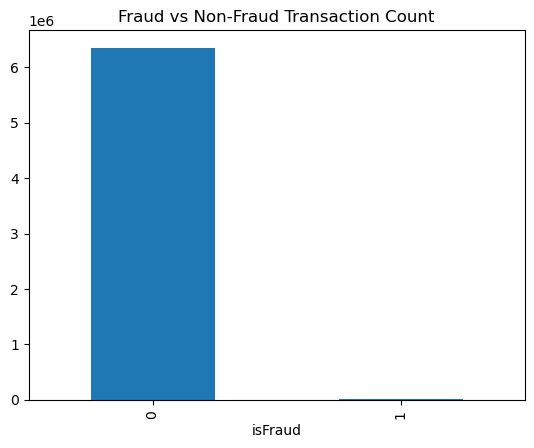

In [31]:
df['isFraud'].value_counts().plot(kind='bar')
plt.title('Fraud vs Non-Fraud Transaction Count')

print(df['isFraud'].value_counts(normalize=True) * 100)

In [34]:
mask = df['isFraud']==1
fraud_trans = df[mask]
fraud_trans.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0
251,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0
252,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0
680,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0


In [37]:
fraud_trans["type"].value_counts()
fraud_trans["type"].value_counts(normalize=True) * 100

type
CASH_OUT    50.11567
TRANSFER    49.88433
Name: proportion, dtype: float64

Cashout and transfer are used roughly the same when it comes to fraudulent transactions

In [38]:
df["type"].value_counts(normalize=True) * 100

type
CASH_OUT    35.166331
PAYMENT     33.814608
CASH_IN     21.992261
TRANSFER     8.375622
DEBIT        0.651178
Name: proportion, dtype: float64

For non-fraud transactions, other transaction types are also used, such as payment, cash in, and debit. This gives me some insight on what features to use in a future model.

In [40]:
#to show number fully and not in scientific notation
pd.options.display.float_format = '{:,.2f}'.format

● oldBalanceOrg: The origin accounts balance before the transaction 
● newBalanceOrg: The origin accounts balance after the transaction 
● oldbalanceDest: The destination accounts balance before the transaction 
● newbalanceDest: The destination accounts balance after the transaction 

In [ ]:
df[df['isFraud'] == 1]['oldbalanceOrg'].agg(['sum', 'mean', 'median', 'count'])

sum      13,548,720,045.71
mean          1,649,667.61
median          438,983.45
count             8,213.00
Name: oldbalanceOrg, dtype: float64

In [47]:
df[df['isFraud'] == 1]['newbalanceOrig'].agg(['sum', 'mean', 'median', 'count'])

sum      1,580,120,685.27
mean           192,392.63
median               0.00
count            8,213.00
Name: newbalanceOrig, dtype: float64

In [48]:
df[df['isFraud'] == 1]['oldbalanceDest'].agg(['sum', 'mean', 'median', 'count'])

sum      4,469,922,121.46
mean           544,249.62
median               0.00
count            8,213.00
Name: oldbalanceDest, dtype: float64

In [49]:
df[df['isFraud'] == 1]['newbalanceDest'].agg(['sum', 'mean', 'median', 'count'])

sum      10,510,238,659.62
mean          1,279,707.62
median            4,676.42
count             8,213.00
Name: newbalanceDest, dtype: float64

In [50]:
df[df['isFraud'] == 0]['oldbalanceOrg'].agg(['sum', 'mean', 'median', 'count'])

sum      5,292,132,595,600.70
mean               832,828.71
median              14,069.00
count            6,354,407.00
Name: oldbalanceOrg, dtype: float64

In [51]:
df[df['isFraud'] == 0]['newbalanceOrig'].agg(['sum', 'mean', 'median', 'count'])

sum      5,439,183,209,286.23
mean               855,970.23
median                   0.00
count            6,354,407.00
Name: newbalanceOrig, dtype: float64

In [53]:
df[df['isFraud'] == 0]['oldbalanceDest'].agg(['sum', 'mean', 'median', 'count'])

sum      6,998,876,515,309.79
mean             1,101,420.87
median             133,311.80
count            6,354,407.00
Name: oldbalanceDest, dtype: float64

In [54]:
df[df['isFraud'] == 0]['newbalanceDest'].agg(['sum', 'mean', 'median', 'count'])

sum      7,783,676,344,467.94
mean             1,224,925.68
median             214,881.70
count            6,354,407.00
Name: newbalanceDest, dtype: float64

In [57]:
df.groupby(['isFraud', 'type'])['amount'].agg(['sum', 'mean', 'median', 'count'])

sum         mean     median    count
isFraud type                                                        
0       CASH_IN  236,367,391,912.46   168,920.24 143,427.71  1399284
        CASH_OUT 388,423,792,980.66   173,917.16 146,946.56  2233384
        DEBIT        227,199,221.28     5,483.67   3,048.99    41432
        PAYMENT   28,093,371,138.37    13,057.60   9,482.19  2151495
        TRANSFER 479,224,774,079.16   906,229.01 486,521.91   528812
1       CASH_OUT   5,989,202,243.83 1,455,102.59 435,516.91     4116
        TRANSFER   6,067,213,184.01 1,480,891.67 445,705.76     4097

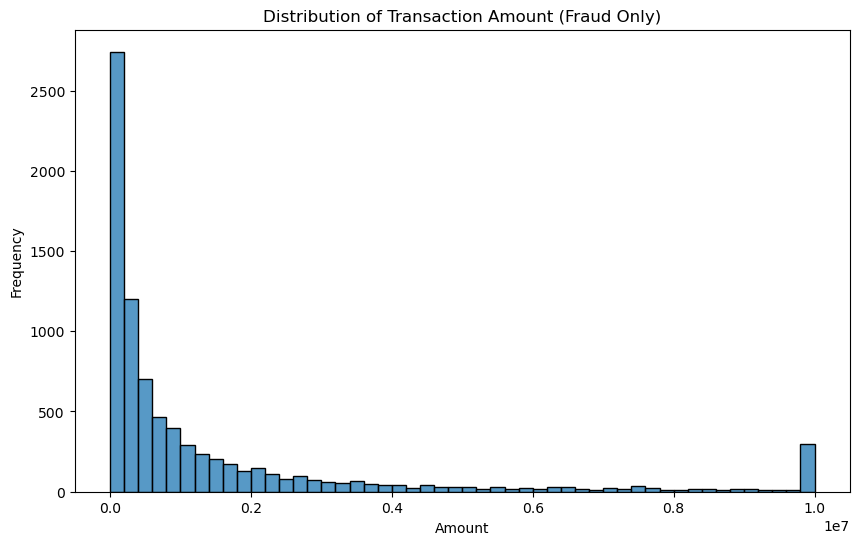

In [58]:
fraud_amount = df[df['isFraud'] == 1]['amount']

plt.figure(figsize=(10, 6))
sns.histplot(fraud_amount, bins=50)
plt.title('Distribution of Transaction Amount (Fraud Only)')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

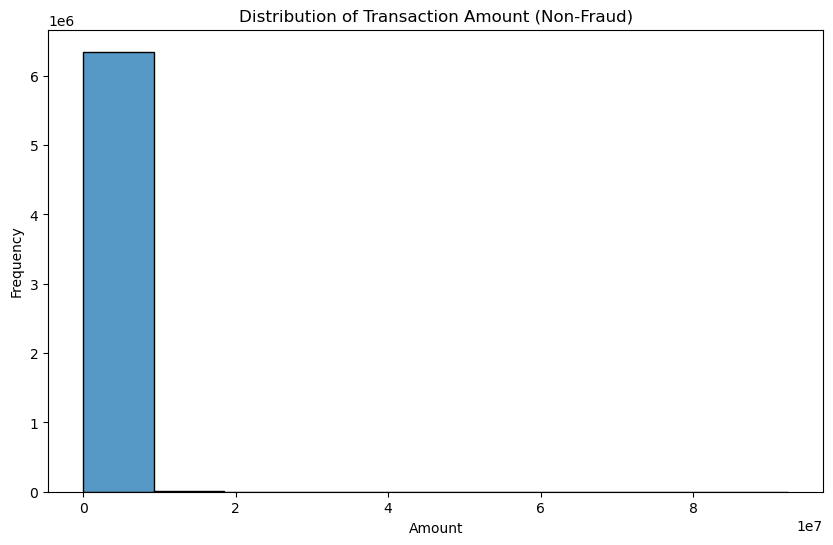

In [62]:
not_fraud_amount = df[df['isFraud'] == 0]['amount']

plt.figure(figsize=(10, 6))
sns.histplot(not_fraud_amount, bins=10)
plt.title('Distribution of Transaction Amount (Non-Fraud)')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

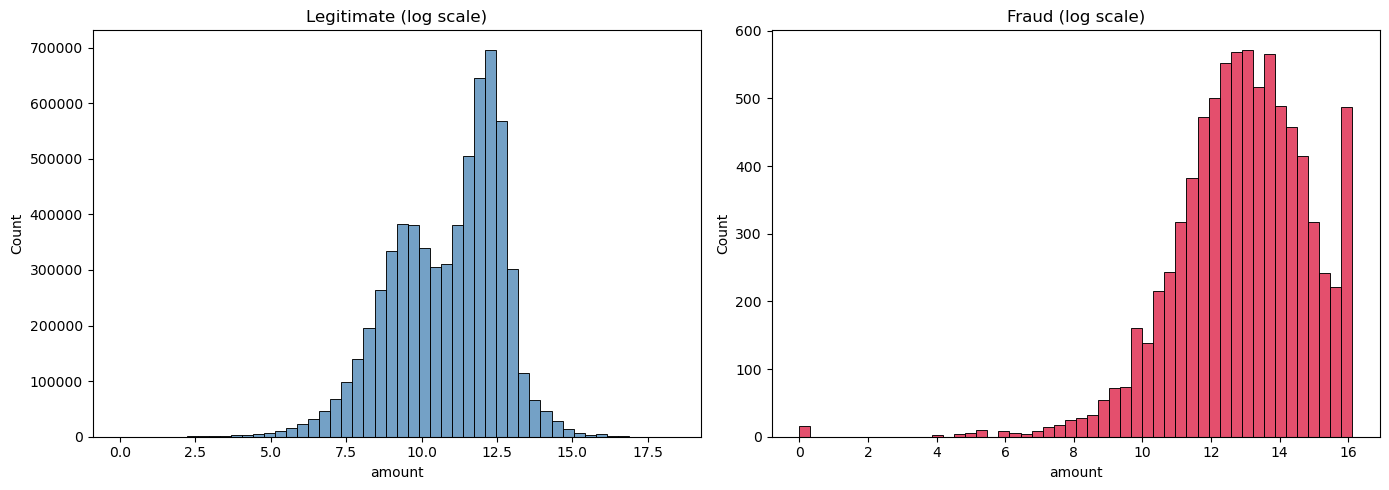

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(np.log1p(df[df['isFraud']==0]['amount']), bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Legitimate (log scale)')

sns.histplot(np.log1p(df[df['isFraud']==1]['amount']), bins=50, ax=axes[1], color='crimson')
axes[1].set_title('Fraud (log scale)')

plt.tight_layout()
plt.show()

In [ ]:
#df.to_csv("cleaned_frauddataset.csv", index=False)